In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import os
from collections import Counter


In [2]:
csv_file = "GP_1750_2000_opium.csv"
if os.path.exists(csv_file):
    df = pd.read_csv(csv_file)
    print(f"Dataset loaded. Shape: {df.shape}")
else:
    print(f"File {csv_file} not found.")


Dataset loaded. Shape: (6776, 23)


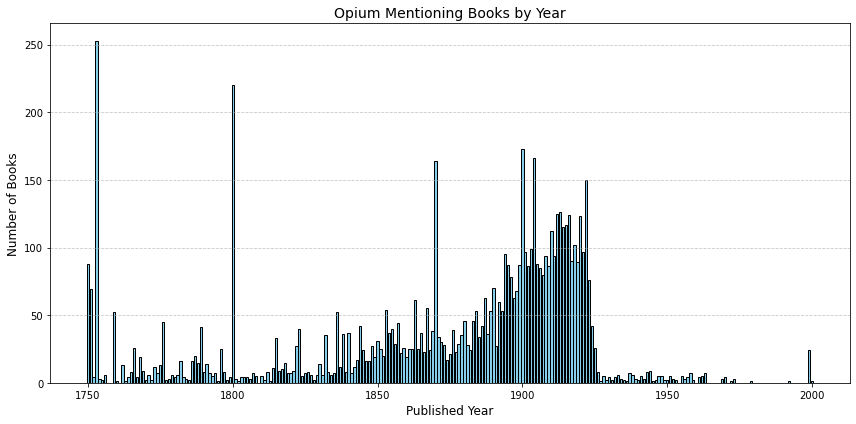

In [3]:
# 1. Books per year distribution
if 'published_year' in df.columns:
    plt.figure(figsize=(12, 6))
    years = pd.to_numeric(df['published_year'], errors='coerce')
    year_counts = years.dropna().value_counts().sort_index()
    plt.bar(year_counts.index, year_counts.values, color='skyblue', edgecolor='black')
    plt.title('Opium Mentioning Books by Year', fontsize=14)
    plt.xlabel('Published Year', fontsize=12)
    plt.ylabel('Number of Books', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("'published_year' column not found.")


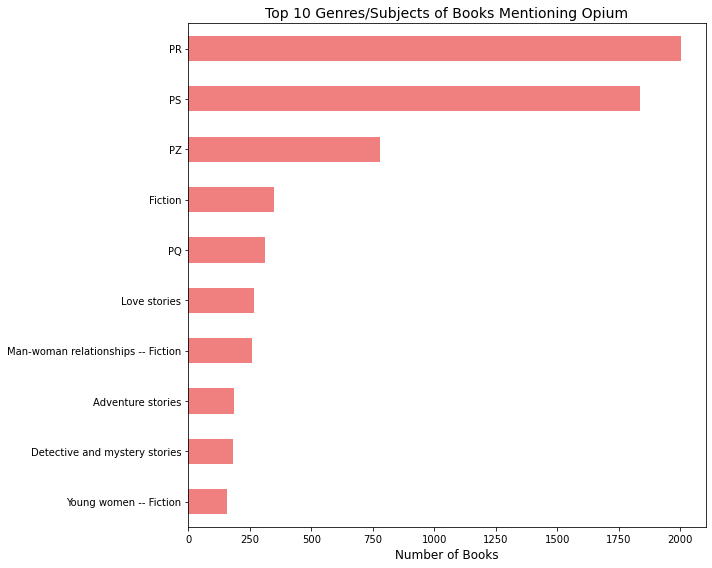

In [4]:
# 2. Top Subjects
if 'Subjects' in df.columns:
    all_subjects = df['Subjects'].dropna().str.split(';').explode().str.strip()
    top_subjects = all_subjects.value_counts().head(10)
    plt.figure(figsize=(10, 8))
    top_subjects.sort_values().plot(kind='barh', color='lightcoral')
    plt.title('Top 10 Genres/Subjects of Books Mentioning Opium', fontsize=14)
    plt.xlabel('Number of Books', fontsize=12)
    plt.tight_layout()
    plt.show()


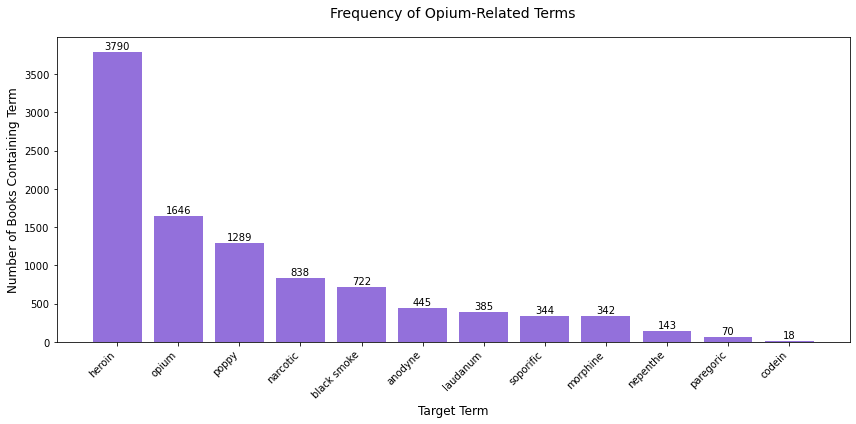

In [5]:
# 3. Term Frequency (using 'Opium Keywords' column)
if 'Opium Keywords' in df.columns:
    term_counts = Counter()
    for row in df['Opium Keywords']:
        if pd.isna(row): continue
        try:
            keywords = ast.literal_eval(row)
            if isinstance(keywords, list):
                term_counts.update(keywords)
            elif isinstance(keywords, str):
                term_counts.update([keywords])
        except Exception:
            if isinstance(row, str):
                term_counts.update([k.strip() for k in row.split(',')])

    top_terms = dict(term_counts.most_common(12))
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(top_terms.keys(), top_terms.values(), color='mediumpurple')
    plt.title('Frequency of Opium-Related Terms', fontsize=14, pad=20)
    plt.xlabel('Target Term', fontsize=12)
    plt.ylabel('Number of Books Containing Term', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontsize=10)
        
    plt.tight_layout()
    plt.show()


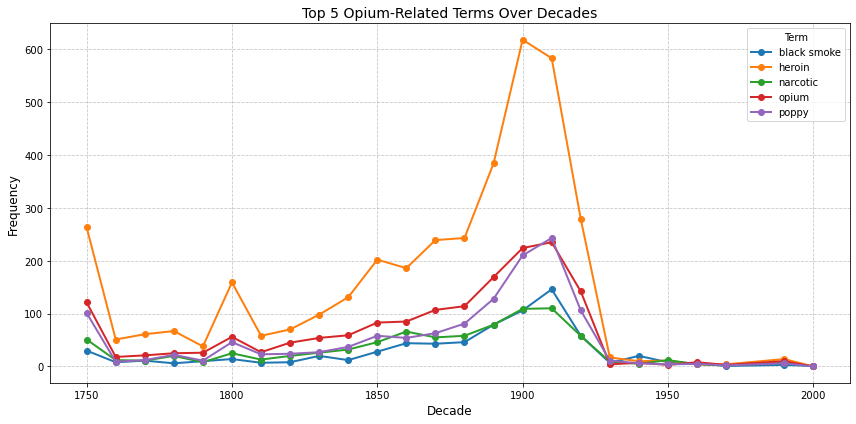

In [6]:
# 4. Terms Over Time (Decades)
if 'Opium Keywords' in df.columns and 'published_year' in df.columns:
    df_terms = df.dropna(subset=['published_year', 'Opium Keywords']).copy()
    df_terms['published_year'] = pd.to_numeric(df_terms['published_year'], errors='coerce')
    df_terms = df_terms.dropna(subset=['published_year'])
    df_terms['decade'] = (df_terms['published_year'] // 10) * 10
    
    records = []
    for idx, row in df_terms.iterrows():
        kw_val = row['Opium Keywords']
        decade = row['decade']
        try:
            kws = ast.literal_eval(kw_val)
            if isinstance(kws, list):
                for k in kws:
                    records.append({'decade': decade, 'term': k})
            elif isinstance(kws, str):
                records.append({'decade': decade, 'term': kws})
        except Exception:
            if isinstance(kw_val, str):
                for k in kw_val.split(','):
                    records.append({'decade': decade, 'term': k.strip()})
                    
    df_expanded = pd.DataFrame(records)
    if not df_expanded.empty:
        top_5_terms = df_expanded['term'].value_counts().head(5).index.tolist()
        df_top5 = df_expanded[df_expanded['term'].isin(top_5_terms)]
        ct = pd.crosstab(df_top5['decade'], df_top5['term'])
        
        plt.figure(figsize=(12, 6))
        for term in ct.columns:
            plt.plot(ct.index, ct[term], marker='o', linewidth=2, label=term)
            
        plt.title('Top 5 Opium-Related Terms Over Decades', fontsize=14)
        plt.xlabel('Decade', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.legend(title='Term')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()


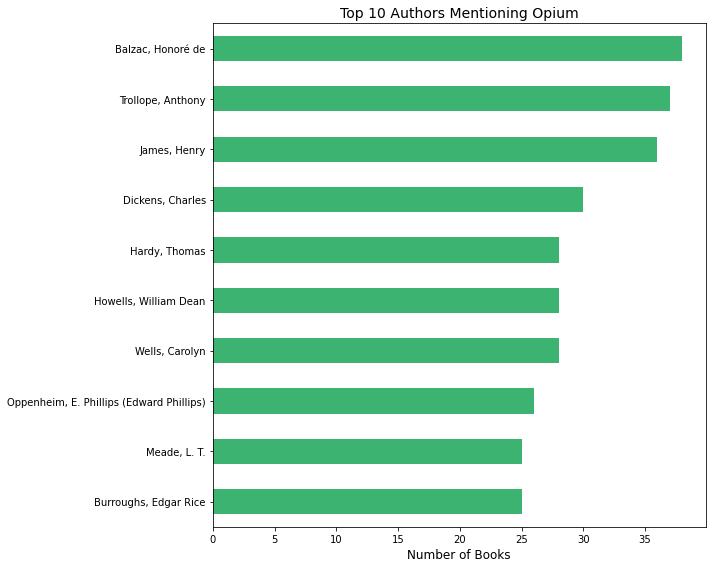

In [7]:
# 5. Top Authors
if 'Authors' in df.columns:
    df_authors = df.dropna(subset=['Authors']).copy()
    all_authors = df_authors['Authors'].str.split(';').explode().str.strip()
    top_authors = all_authors.value_counts().head(10)
    
    plt.figure(figsize=(10, 8))
    top_authors.sort_values().plot(kind='barh', color='mediumseagreen')
    plt.title('Top 10 Authors Mentioning Opium', fontsize=14)
    plt.xlabel('Number of Books', fontsize=12)
    plt.tight_layout()
    plt.show()
